<h1><font color ="Blue"><center> GIS Applications in Engineering</h1>

<h2><font color ="Red"><center> Shaseevarajan Sivanantharajah</h1>

<h3><font color ="Black"><center> Assignment 5</h1>

**Problem Statement**
1. Take lat-long for El Paso, San Antonio, Austin, Dallas, Houston and Beaumont in a CSV file and create a pandas Geodataframe using the Shapely Point Object.
2. Create two line strings - 1) Line Connecting El Paso, San Antonio, Houston and Beaumont (This is approximately I-10) 2) Create a line connecting Austin and San Antonio (this is I-35 approiximately)
3. Use the linestrings to create a line geodataframe
4. Create a Polygon connecting San Antonio, Austin, Dallas, Houston (use San Antonio to close the loop). This is the Texas Triangle Create a Geopandas Geodataframe
5. Compute the area of the Texas Triangle in sq. miles
6. Compute Approximately the number of People who live within the Texas Triangle.

In [2]:
import os
import pandas as pd
import geopandas as gpd
from shapely import Point,LineString,Polygon
from matplotlib import pyplot as plt

In [5]:
path = "/home/harris/Downloads/Shasee/Assignment5"
os.chdir(path)

In [19]:
# City coordinates
data = {
    "City": ["El Paso", "San Antonio", "Austin", "Dallas", "Houston", "Beaumont"],
    "Latitude": [31.7619, 29.4241, 30.2672, 32.7767, 29.7604, 30.0802],
    "Longitude": [-106.4850, -98.4936, -97.7431, -96.7970, -95.3698, -94.1266]
}

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv("TXcities.csv", index=False)

In [20]:
fname = ('TXcities.csv')
a = pd.read_csv(fname)

In [21]:
a.head()

,City,Latitude,Longitude
0,El Paso,31.7619,-106.4850
1,San Antonio,29.4241,-98.4936
2,Austin,30.2672,-97.7431
3,Dallas,32.7767,-96.7970
4,Houston,29.7604,-95.3698


In [25]:
#Convert to a dictionary
#Zip function is used to iterate over multiple objects
#Dict is used to define the dictionary object
TXcities = dict(zip(a['City'],zip(a['Longitude'],a['Latitude'])))
TXcities

{'El Paso': (-106.485, 31.7619),
 'San Antonio': (-98.4936, 29.4241),
 'Austin': (-97.7431, 30.2672),
 'Dallas': (-96.797, 32.7767),
 'Houston': (-95.3698, 29.7604),
 'Beaumont': (-94.1266, 30.0802)}

In [26]:
#Use the Point object of Shapely to create a set of Points
#Iterate over the dictionary to obtain the lat-long
geom = [Point(coord) for coord in TXcities.values()]
geom

[<POINT (-106.485 31.762)>,
 <POINT (-98.494 29.424)>,
 <POINT (-97.743 30.267)>,
 <POINT (-96.797 32.777)>,
 <POINT (-95.37 29.76)>,
 <POINT (-94.127 30.08)>]

In [44]:
# Create a Geopandas Data Frame
TXcitiesgpd = gpd.GeoDataFrame({"City":list(TXcities.keys())},geometry=geom,crs='EPSG:4326')
TXcitiesgpd.head()

,City,geometry
0,El Paso,POINT (-106.485 31.7619)
1,San Antonio,POINT (-98.4936 29.4241)
2,Austin,POINT (-97.7431 30.2672)
3,Dallas,POINT (-96.797 32.7767)
4,Houston,POINT (-95.3698 29.7604)


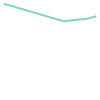

In [48]:
#Create LineSrings for Approx I10 and approx I35
roadI10 = LineString([TXcities['El Paso'],TXcities['San Antonio'],TXcities['Houston'],TXcities['Beaumont']])
roadI10

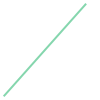

In [49]:
roadI35 = LineString([TXcities['Austin'],TXcities['San Antonio']])
roadI35

In [53]:
roads = gpd.GeoDataFrame({"HWY":["I10Approx","I35ApproxASA"]}, geometry= [roadI10,roadI35],crs='EPSG:4326')
roads.head()

,HWY,geometry
0,I10Approx,"LINESTRING (-106.485 31.7619, -98.4936 29.4241..."
1,I35ApproxASA,"LINESTRING (-97.7431 30.2672, -98.4936 29.4241)"


In [64]:
fname1 = "County_Boundaries.shp"
txbnd = gpd.read_file(fname1)
txgcs = txbnd.to_crs('EPSG:4326')
txgcsd = txgcs.dissolve().geometry.exterior


<function matplotlib.pyplot.show(close=None, block=None)>

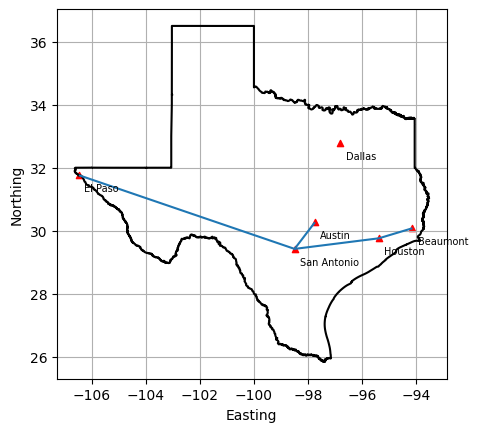

In [72]:
ax = txgcsd.plot(edgecolor = 'black', facecolor = 'none')
roads.plot(ax=ax)
TXcitiesgpd.plot(ax=ax,marker = '^',color='red', markersize=20)
for x, y, label in zip(TXcitiesgpd.geometry.x, TXcitiesgpd.geometry.y, TXcitiesgpd['City']):
    ax.text(x + 0.2, y - 0.5, label, fontsize=7, color='black')
plt.grid()
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.show